In [6]:
# student performance analysis using python
# PCA- to find most contributing factor and recude the size to smaller size to analyze the data
# define problem, import libraries, load, explore, clean, analyize, visualize, conclusion

In [7]:
# Using goodreads books, kaggle dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load the dataset as dataframe
df = pd.read_csv(
    "books.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8"
)

df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [10]:
print("Shape: ",df.shape) #rows,columns
print(df.columns) # column name
df.dtypes  #data types and no.of columns for that
df.sample(5)  #any 5 rows

Shape:  (11119, 12)
Index(['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13',
       'language_code', '  num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='str')


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
2346,8548,Driving Force,Dick Francis,3.96,0449221393,9780449221396,eng,384,2635,107,12/29/1993,Fawcett Books
8400,32331,Air Gear Vol. 4 (Air Gear #4),Oh! Great/大暮 維人,4.07,0345492811,9780345492814,en-GB,224,467,2,5/1/2007,Del Rey
7027,26697,The Philosophy of Antonio Negri Volume One: R...,Timothy S. Murphy/Abdul-Karim Mustapha,4.12,0745323375,9780745323374,eng,265,8,1,7/20/2005,Pluto Press
7686,29603,20 000 Leagues Under the Sea,Ron Miller/Jules Verne/Paul Wright,3.76,0751370738,9780751370737,eng,64,34,4,10/8/1998,Prentice Hall
4691,16893,The Crack-Up,F. Scott Fitzgerald/Edmund Wilson,3.92,0811212475,9780811212472,eng,347,2477,133,4/30/2003,New Directions Publishing Corporation


In [11]:
df.tail() #last 5 rows

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
11114,45631,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,1560254416,9781560254416,eng,512,156,20,12/21/2004,Da Capo Press
11115,45633,You Bright and Risen Angels,William T. Vollmann,4.08,0140110879,9780140110876,eng,635,783,56,12/1/1988,Penguin Books
11116,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,0140131965,9780140131963,eng,415,820,95,8/1/1993,Penguin Books
11117,45639,Poor People,William T. Vollmann,3.72,0060878827,9780060878825,eng,434,769,139,2/27/2007,Ecco
11118,45641,Las aventuras de Tom Sawyer,Mark Twain,3.91,8497646983,9788497646987,spa,272,113,12,5/28/2006,Edimat Libros


In [12]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 11119 entries, 0 to 11118
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11119 non-null  int64  
 1   title               11119 non-null  str    
 2   authors             11119 non-null  str    
 3   average_rating      11119 non-null  float64
 4   isbn                11119 non-null  str    
 5   isbn13              11119 non-null  int64  
 6   language_code       11119 non-null  str    
 7     num_pages         11119 non-null  int64  
 8   ratings_count       11119 non-null  int64  
 9   text_reviews_count  11119 non-null  int64  
 10  publication_date    11119 non-null  str    
 11  publisher           11119 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.0 MB


,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11119.000000,11119.000000,1.111900e+04,11119.000000,1.111900e+04,11119.000000
mean,21308.966184,3.934135,9.759873e+12,336.439788,1.794832e+04,542.167371
std,13093.071002,0.350384,4.430554e+11,241.177969,1.125190e+05,2577.069549
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780586e+12,299.000000,7.450000e+02,47.000000
75%,32103.500000,4.135000,9.780873e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [13]:
df.isnull().sum()

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

In [14]:
print("Duplicate rows: ",df.duplicated().sum())

Duplicate rows:  0


In [15]:
df.dtypes

bookID                  int64
title                     str
authors                   str
average_rating        float64
isbn                      str
isbn13                  int64
language_code             str
  num_pages             int64
ratings_count           int64
text_reviews_count      int64
publication_date          str
publisher                 str
dtype: object

In [16]:
df['authors'].unique()

<StringArray>
[                                 'J.K. Rowling/Mary GrandPré',
                                                'J.K. Rowling',
                                      'W. Frederick Zimmerman',
                                               'Douglas Adams',
                                   'Douglas Adams/Stephen Fry',
                                                 'Bill Bryson',
                                              'J.R.R. Tolkien',
                                    'J.R.R. Tolkien/Alan  Lee',
               'Chris   Smith/Christopher  Lee/Richard Taylor',
                                                 'Jude Fisher',
 ...
                                            'Alexander Hunter',
                                    'Roald Dahl/Horacio Elena',
                                       'David Wood/Roald Dahl',
                     'Dave Crane/Eric Pascarello/Darren James',
                                                'Rosa Montero',
                     

In [17]:
df['language_code'].unique()

<StringArray>
[  'eng', 'en-US',   'fre',   'spa', 'en-GB',   'mul',   'grc',   'enm',
 'en-CA',   'ger',   'jpn',   'ara',    'nl',   'zho',   'lat',   'por',
   'srp',   'ita',   'rus',   'msa',   'glg',   'wel',   'swe',   'nor',
   'tur',   'gla',   'ale']
Length: 27, dtype: str

In [18]:
# remove extra spaces
df['authors']=df['authors'].str.strip()
df['publisher']=df['publisher'].str.strip()
df["title"] = df["title"].str.strip()

In [19]:
df.isnull().sum()

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

In [20]:
df["language_code"].value_counts()

language_code
eng      8906
en-US    1406
spa       218
en-GB     214
fre       144
ger        99
jpn        46
mul        19
zho        14
grc        11
por        10
en-CA       7
ita         5
enm         3
lat         3
rus         2
swe         2
ara         1
nl          1
srp         1
msa         1
glg         1
wel         1
nor         1
tur         1
gla         1
ale         1
Name: count, dtype: int64

In [21]:
df['language_code']=df['language_code'].replace({
    "en-CA":"eng",
    "en-US": "eng",
    "en-GB": "eng"
})

In [22]:
df['language_code'].value_counts()

language_code
eng    10533
spa      218
fre      144
ger       99
jpn       46
mul       19
zho       14
grc       11
por       10
ita        5
enm        3
lat        3
rus        2
swe        2
ara        1
nl         1
srp        1
msa        1
glg        1
wel        1
nor        1
tur        1
gla        1
ale        1
Name: count, dtype: int64

In [23]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 11119 entries, 0 to 11118
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11119 non-null  int64  
 1   title               11119 non-null  str    
 2   authors             11119 non-null  str    
 3   average_rating      11119 non-null  float64
 4   isbn                11119 non-null  str    
 5   isbn13              11119 non-null  int64  
 6   language_code       11119 non-null  str    
 7     num_pages         11119 non-null  int64  
 8   ratings_count       11119 non-null  int64  
 9   text_reviews_count  11119 non-null  int64  
 10  publication_date    11119 non-null  str    
 11  publisher           11119 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.0 MB


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [ ]:
#count books by each author
authors=df['authors'].value_counts().head()
print(authors)
#tells which author contributes more to the dataset 

authors
Stephen King        40
P.G. Wodehouse      40
Rumiko Takahashi    39
Orson Scott Card    35
Agatha Christie     33
Name: count, dtype: int64


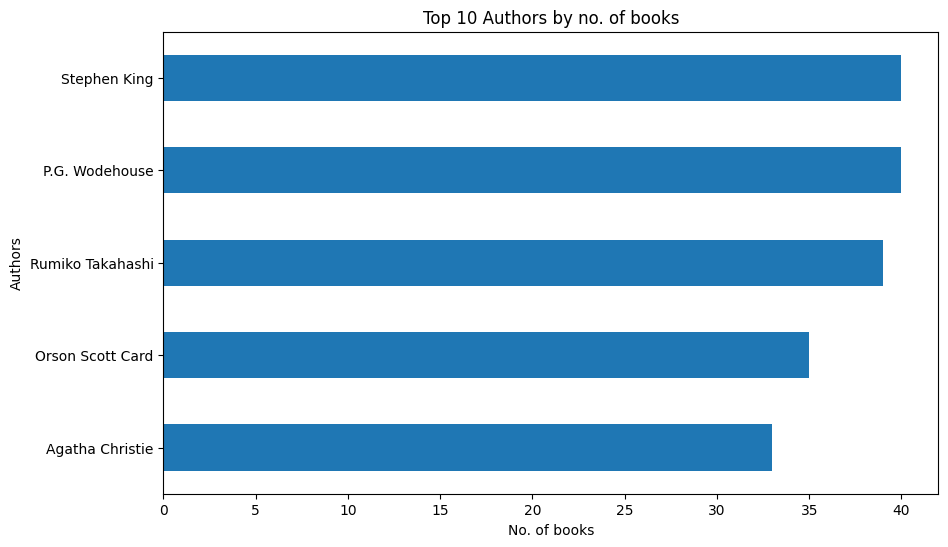

In [28]:
plt.figure(figsize=(10,6))
authors.sort_values().plot(kind='barh')
plt.title("Top 10 Authors by no. of books")
plt.xlabel("No. of books")
plt.ylabel("Authors")
plt.show()

publisher
Vintage             318
Penguin Books       261
Penguin Classics    184
Mariner Books       150
Ballantine Books    144
Harper Perennial    112
HarperCollins       112
Pocket Books        111
Bantam              110
VIZ Media LLC        88
Name: count, dtype: int64


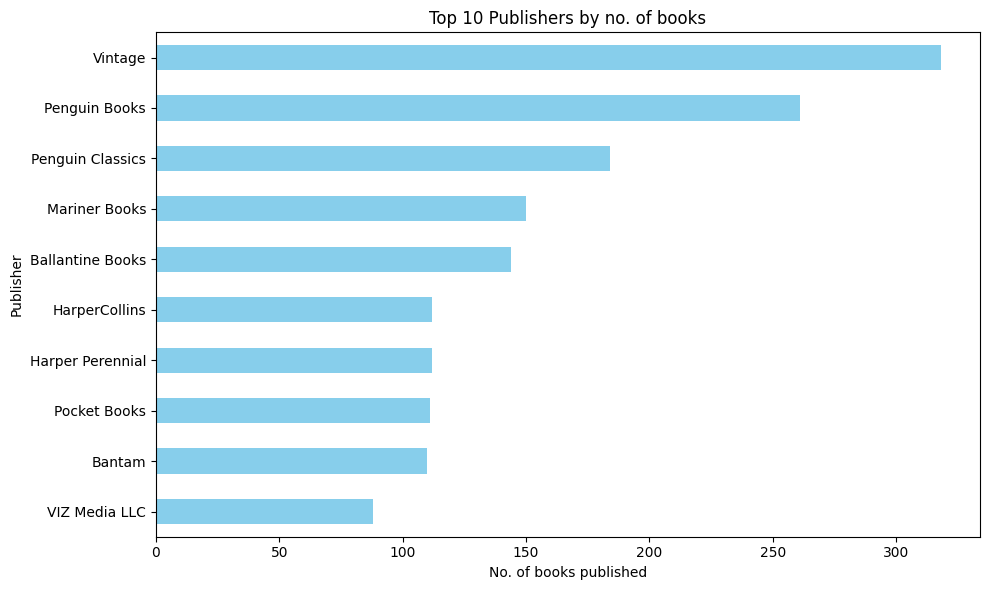

In [29]:
#publishers who published the most books
publish=df['publisher'].value_counts().head(10)
print(publish)

plt.figure(figsize=(10,6))
publish.sort_values().plot(kind='barh',color='skyblue')
plt.title("Top 10 Publishers by no. of books")
plt.xlabel("No. of books published")
plt.ylabel("Publisher")
plt.tight_layout()
plt.show()
# majoy publishing companies 

In [30]:
# Top 10 authors
top_authors = df["authors"].value_counts().head(10).index

# Filter dataset
author_pub = df[df["authors"].isin(top_authors)]

# Crosstab
author_publisher = pd.crosstab(author_pub["authors"], author_pub["publisher"])

# Top publishers only (to keep graph readable)
author_publisher = author_publisher.loc[:, author_publisher.sum().sort_values(ascending=False).head(10).index]

author_publisher

publisher,G.P. Putnam's Sons,Tor Books,Harry N. Abrams,小学館,VIZ Media LLC,Viz Media,Signet,DAW,Black Dog & Leventhal Publishers,Wizards of the Coast
authors,,,,,,,,,,
Agatha Christie,1,0,0,0,0,0,4,0,9,0
Dick Francis,20,0,0,0,0,0,0,0,0,0
Margaret Weis/Tracy Hickman,0,0,0,0,0,0,0,0,0,9
Mercedes Lackey,0,0,0,0,0,0,0,11,0,0
Orson Scott Card,0,13,0,0,0,0,0,0,0,0
P.G. Wodehouse,0,0,16,0,0,0,0,0,0,0
Piers Anthony,0,7,0,0,0,0,0,0,0,0
Rumiko Takahashi,0,0,0,13,12,12,0,0,0,0
Sandra Brown,0,0,0,0,0,0,0,0,0,0


C:\Users\DELL\AppData\Local\Temp\ipykernel_8124\4153641261.py:10: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_8124\4153641261.py:10: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_8124\4153641261.py:10: UserWarning: Glyph 39208 (\N{CJK UNIFIED IDEOGRAPH-9928}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39208 (\N{CJK UNIFIED IDEOGRAPH-9928}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


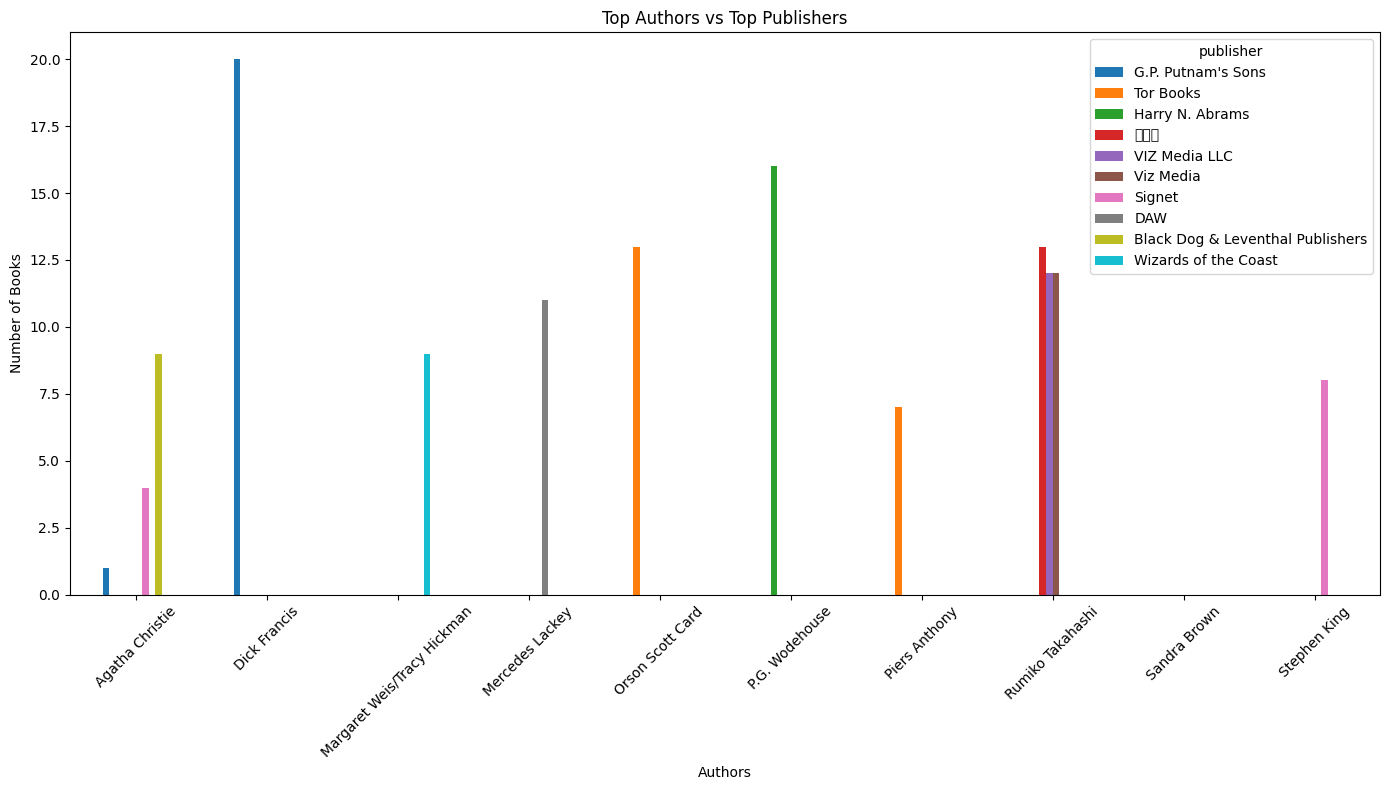

In [31]:
plt.figure(figsize=(14,8))

author_publisher.plot(kind="bar", figsize=(14,8))

plt.title("Top Authors vs Top Publishers")
plt.xlabel("Authors")
plt.ylabel("Number of Books")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()